# Data understanding

In [1]:
import os
import glob
import random
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [9]:


# Stel ROOT_DIR in relatief aan het notebook
ROOT_DIR = Path.cwd() / "routeeventlog"

OUTPUT_CSV = "data_understanding_overview.csv"
SAMPLE_SIZE = 20000
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

print(ROOT_DIR)

ROOT_DIR.exists()

c:\Users\ICT\Documents\Semester 1\Periode 2\GitCodeProj\AI-Waste_Vision_POC\routeeventlog


True

In [10]:
# Scan the directory structure and collect data
records = []

if ROOT_DIR.exists():
	for subfolder in ROOT_DIR.iterdir():
		if subfolder.is_dir():
			# Count images in this subfolder
			image_count = 0
			for file in subfolder.iterdir():
				if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
					image_count += 1
			
			# Extract category information from folder name
			folder_name = subfolder.name
			parts = folder_name.split('_')
			hoofdcategorie = parts[0] if parts else folder_name
			
			records.append({
				'subfolder': folder_name,
				'hoofdcategorie': hoofdcategorie,
				'aantal_fotos': image_count,
				'pad': str(subfolder)
			})

In [11]:
# Create DataFrame from the records
test_df = pd.DataFrame(records)

# Display basic information about the DataFrame
print(f"DataFrame shape: {test_df.shape}")
print(f"Columns: {test_df.columns.tolist()}")
print("\nFirst few rows:")
print(test_df.head())

# Show data types
print(f"\nData types:")
print(test_df.dtypes)       
# Basic statistics
print(f"\nBasic statistics:")
print(f"Total number of subfolders: {len(test_df)}")
print(f"Total number of photos: {test_df['aantal_fotos'].sum()}")
print(f"Number of main categories: {test_df['hoofdcategorie'].nunique()}")



DataFrame shape: (29, 4)
Columns: ['subfolder', 'hoofdcategorie', 'aantal_fotos', 'pad']

First few rows:
                              subfolder                        hoofdcategorie  \
0  0a4cde88-b495-4563-ac21-92557a3f236f  0a4cde88-b495-4563-ac21-92557a3f236f   
1  0eb5fd40-2248-40f5-a9f0-c26d9bf7a60a  0eb5fd40-2248-40f5-a9f0-c26d9bf7a60a   
2  226b9a12-05f4-4b89-a71a-4bd411fc3f43  226b9a12-05f4-4b89-a71a-4bd411fc3f43   
3  27316bd8-a43b-4e01-a473-7296448ce944  27316bd8-a43b-4e01-a473-7296448ce944   
4  2fe482ee-1b4a-430f-b76d-d886ad3c24ca  2fe482ee-1b4a-430f-b76d-d886ad3c24ca   

   aantal_fotos                                                pad  
0             0  c:\Users\ICT\Documents\Semester 1\Periode 2\Gi...  
1             0  c:\Users\ICT\Documents\Semester 1\Periode 2\Gi...  
2             0  c:\Users\ICT\Documents\Semester 1\Periode 2\Gi...  
3             0  c:\Users\ICT\Documents\Semester 1\Periode 2\Gi...  
4             0  c:\Users\ICT\Documents\Semester 1\Periode 2\G

In [12]:
# Collect 1000 random images from the directory structure for testing
test_images = []
collected_count = 0
target_count = 1000

print("Collecting test images from directory structure...")

# Iterate through all subfolders to find actual image files
for subfolder_path in ROOT_DIR.iterdir():
    if subfolder_path.is_dir() and collected_count < target_count:
        # Look for images in the subfolder and its subdirectories
        for image_path in subfolder_path.rglob("*"):
            if (image_path.is_file() and 
                image_path.suffix.lower() in IMAGE_EXTENSIONS and 
                collected_count < target_count):
                
                test_images.append({
                    'image_path': str(image_path),
                    'subfolder': subfolder_path.name,
                    'relative_path': str(image_path.relative_to(ROOT_DIR))
                })
                collected_count += 1
                
                # Print progress every 100 images
                if collected_count % 100 == 0:
                    print(f"Collected {collected_count} images...")

# Create DataFrame from collected images
if test_images:
    test_sample_df = pd.DataFrame(test_images)
    print(f"\nSuccessfully collected {len(test_sample_df)} test images")
    print(f"Sample paths:")
    print(test_sample_df['relative_path'].head())
    
    # Show distribution across subfolders
    print(f"\nDistribution across subfolders:")
    print(test_sample_df['subfolder'].value_counts().head(10))
    
    # Save to CSV for later use
    test_sample_df.to_csv('test_images_sample.csv', index=False)
    print(f"\nTest sample saved to 'test_images_sample.csv'")
    
else:
    print("No images found in the directory structure. Please check the ROOT_DIR path.")
    print(f"ROOT_DIR: {ROOT_DIR}")
    print(f"Directory exists: {ROOT_DIR.exists()}")

Collected 100 images...
Collected 200 images...
Collected 300 images...
Collected 400 images...
Collected 500 images...
Collected 600 images...
Collected 700 images...
Collected 800 images...
Collected 900 images...
Collected 1000 images...

Successfully collected 1000 test images
Sample paths:
0    0a4cde88-b495-4563-ac21-92557a3f236f\0017c98a-...
1    0a4cde88-b495-4563-ac21-92557a3f236f\00242975-...
2    0a4cde88-b495-4563-ac21-92557a3f236f\00242975-...
3    0a4cde88-b495-4563-ac21-92557a3f236f\00242975-...
4    0a4cde88-b495-4563-ac21-92557a3f236f\0033718e-...
Name: relative_path, dtype: object

Distribution across subfolders:
subfolder
0a4cde88-b495-4563-ac21-92557a3f236f    1000
Name: count, dtype: int64

Test sample saved to 'test_images_sample.csv'


In [13]:
# Load the labels data
labels_df = pd.read_csv('labels.csv')
print(labels_df.head())
print(f"Shape of labels data: {labels_df.shape}")

                                          image_path  label
0  routeeventlog/b39f42d4-b0f0-4528-b593-e31a8c5d...     -1
1  routeeventlog/b39f42d4-b0f0-4528-b593-e31a8c5d...     -1
2  routeeventlog/923f4a90-a6b6-4e60-b8e8-08a3c76a...      1
3  routeeventlog/923f4a90-a6b6-4e60-b8e8-08a3c76a...      1
4  routeeventlog/b39f42d4-b0f0-4528-b593-e31a8c5d...      0
Shape of labels data: (2328, 2)


Label distribution:
label
-1    1322
 0     546
 1     460
Name: count, dtype: int64


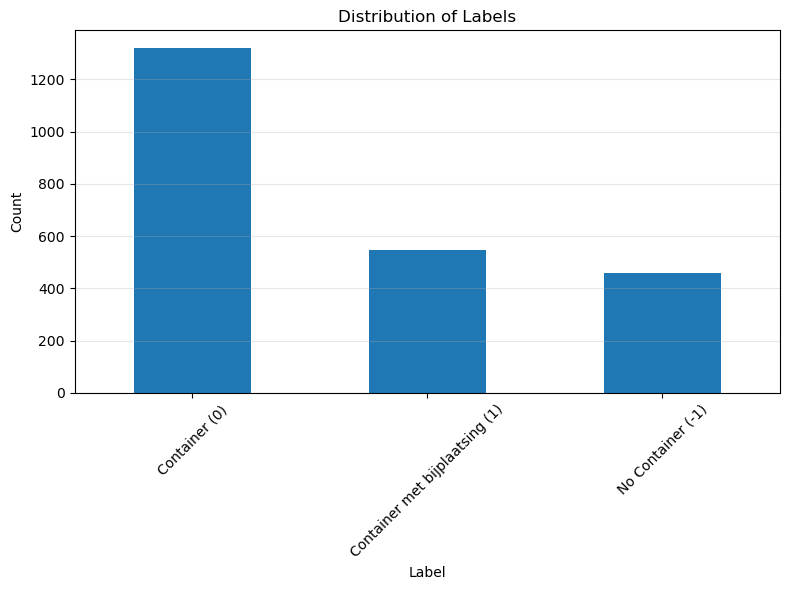

In [14]:
# Check the distribution of labels
print("Label distribution:")
print(labels_df['label'].value_counts().sort_index())

# Visualize the label distribution
plt.figure(figsize=(8, 6))
labels_df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Container (0)', 'Container met bijplaatsing (1)', 'No Container (-1)'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Data preparation 

In [16]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path("labels.csv")   # pas aan naar jouw labelbestand
ROOT_DIR = Path.cwd() / "routeeventlog"

df = pd.read_csv(CSV_PATH, header=None, names=["raw_path", "label"])

def fix_path(p):
    # 1. Backslashes → slashes
    p = p.replace("\\", "/")

    # 2. Alleen deel na foldernaam pakken (ProjectData of routeeventlog)
    parts = p.split("/")
    if "routeeventlog" in parts:
        idx = parts.index("routeeventlog")
    elif "ProjectData" in parts:
        idx = parts.index("ProjectData")
    else:
        return None  # onbekend path

    rel = "/".join(parts[idx+1:])  # alles ná de folder

    # 3. Nieuw pad opbouwen op basis van ROOT_DIR
    fixed = ROOT_DIR / rel

    return fixed

df["fixed_path"] = df["raw_path"].apply(fix_path)
df["exists"] = df["fixed_path"].apply(lambda p: p is not None and Path(p).exists())

df_missing = df[~df["exists"]]
df_ok = df[df["exists"]]

print(f"✔ {len(df_ok)} images gevonden")
print(f"✘ {len(df_missing)} images ontbreken")

df_ok.to_csv("labels_clean.csv", index=False)


✔ 2328 images gevonden
✘ 1 images ontbreken


In [17]:
# Prepare YOLO dataset config and verify YOLO-format labels
from pathlib import Path
import pandas as pd
import shutil
import yaml

ROOT_DIR = Path.cwd() / "routeeventlog"
LABELS_CSV = Path("labels.csv")  # pas aan als jouw CSV anders heet
DATASET_DIR = Path("datasets/containers")
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

DATASET_DIR.mkdir(parents=True, exist_ok=True)
(DATASET_DIR / "images" / "train").mkdir(parents=True, exist_ok=True)
(DATASET_DIR / "images" / "val").mkdir(parents=True, exist_ok=True)
(DATASET_DIR / "labels" / "train").mkdir(parents=True, exist_ok=True)
(DATASET_DIR / "labels" / "val").mkdir(parents=True, exist_ok=True)

# Laad CSV (verwacht twee kolommen: path,label). Mocht jouw CSV header hebben, pas header arg aan.
df = pd.read_csv(LABELS_CSV, header=None, names=["raw_path","label"])
print(f"CSV total rows: {len(df)}")

# Normaal functie: zet backslashes om en map naar ROOT_DIR
def normalize_and_map(raw_path):
    p = str(raw_path).replace("\\\\","/").replace("\\","/")  # unify slashes
    parts = p.split("/")
    if "routeeventlog" in parts:
        idx = parts.index("routeeventlog")
        rel = "/".join(parts[idx+1:])
    elif "ProjectData" in parts:
        idx = parts.index("ProjectData")
        rel = "/".join(parts[idx+1:])
    else:
        rel = p.lstrip("/")
    return ROOT_DIR / rel

df["abs_path"] = df["raw_path"].apply(normalize_and_map)
df["exists"] = df["abs_path"].apply(lambda p: Path(p).exists())

found = df['exists'].sum()
print(f"Found existing image files: {found} / {len(df)}")

# Filter only existing files
df_ok = df[df["exists"]].copy()

# Collapse labels to single class 'container' (0). (0 and 1 -> container). Drop -1 implicitly if file missing
df_ok["yolo_class"] = 0

# Train/val split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_ok, test_size=0.2, random_state=42, shuffle=True)

def create_symlink_or_copy(src, dst):
    try:
        dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists():
            dst.symlink_to(src)
    except Exception:
        shutil.copy2(src, dst)

# Create files and labels into dataset folders
for subset_name, subset_df in [("train", train_df), ("val", val_df)]:
    for _, row in subset_df.iterrows():
        src_img = Path(row["abs_path"])
        dst_img = DATASET_DIR / "images" / subset_name / src_img.name
        create_symlink_or_copy(src_img, dst_img)
        # expected YOLO label file next to original image with same basename + .txt
        src_label = src_img.with_suffix(".txt")
        dst_label = DATASET_DIR / "labels" / subset_name / src_img.with_suffix(".txt").name
        if src_label.exists():
            create_symlink_or_copy(src_label, dst_label)
        else:
            # create placeholder empty label file (no boxes) - training DETECTION with empty label files will NOT learn boxes
            dst_label.parent.mkdir(parents=True, exist_ok=True)
            if not dst_label.exists():
                dst_label.write_text("")  # empty file

print(f"Prepared dataset images: {len(list((DATASET_DIR/'images'/'train').glob('*')))} train, {len(list((DATASET_DIR/'images'/'val').glob('*')))} val")

# Count how many label txts are non-empty (i.e. contain bbox lines)
def count_nonempty_label_files(label_dir):
    count = 0
    for p in Path(label_dir).glob("*.txt"):
        if p.stat().st_size > 0:
            count += 1
    return count

train_label_nonempty = count_nonempty_label_files(DATASET_DIR/"labels"/"train")
val_label_nonempty = count_nonempty_label_files(DATASET_DIR/"labels"/"val")
print(f"Non-empty label files: train={train_label_nonempty}, val={val_label_nonempty}")

# Create dataset yaml
dataset_yaml = {
    'path': str(Path.cwd()),
    'train': str(DATASET_DIR / 'images' / 'train'),
    'val': str(DATASET_DIR / 'images' / 'val'),
    'names': {0: 'container'}
}

with open('dataset_containers.yaml', 'w') as f:
    yaml.dump(dataset_yaml, f)

print("\\nCreated dataset_containers.yaml:")
print(open('dataset_containers.yaml').read())



CSV total rows: 2329
Found existing image files: 2328 / 2329
Prepared dataset images: 1862 train, 466 val
Non-empty label files: train=0, val=0
\nCreated dataset_containers.yaml:
names:
  0: container
path: c:\Users\ICT\Documents\Semester 1\Periode 2\GitCodeProj\AI-Waste_Vision_POC
train: datasets\containers\images\train
val: datasets\containers\images\val



In [24]:
# Initialize YOLOv8m (pretrained) and show info
from ultralytics import YOLO

MODEL_NAME = "yolov8m.pt"  # of "yolov8l.pt" voor meer capaciteit
model = YOLO(MODEL_NAME)
print("Model loaded:", MODEL_NAME)
model.info()


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ICT\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded: yolov8m.pt
YOLOv8m summary: 169 layers, 25,902,640 parameters, 0 gradients, 79.3 GFLOPs


(169, 25902640, 0, 79.3204224)

In [25]:
results = model.train(
    data='dataset_containers.yaml',
    epochs=1,
    imgsz=640,
    batch=8,
    device='cpu',   # ← Force CPU
    project='runs/detect',
    name='container_detection',
    save=True,
    plots=True,
    verbose=True
)

print("Training completed!")
print(f"Best weights saved at: {results.save_dir}")

Ultralytics 8.3.229  Python-3.12.7 torch-2.9.1+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_containers.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=container_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

C:\Users\ICT\AppData\Roaming\Python\Python312\site-packages\ultralytics\utils\metrics.py:650: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ICT\AppData\Roaming\Python\Python312\site-packages\ultralytics\utils\metrics.py:694: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\ICT\AppData\Roaming\Python\Python312\site-packages\ultralytics\utils\metrics.py:694: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret

                   all        466          0          0          0          0          0
WARNING no labels found in detect set, can not compute metrics without labels

1 epochs completed in 0.635 hours.
Optimizer stripped from C:\Users\ICT\Documents\Semester 1\Periode 2\GitCodeProj\AI-Waste_Vision_POC\runs\detect\container_detection\weights\last.pt, 52.0MB
Optimizer stripped from C:\Users\ICT\Documents\Semester 1\Periode 2\GitCodeProj\AI-Waste_Vision_POC\runs\detect\container_detection\weights\best.pt, 52.0MB

Validating C:\Users\ICT\Documents\Semester 1\Periode 2\GitCodeProj\AI-Waste_Vision_POC\runs\detect\container_detection\weights\best.pt...
Ultralytics 8.3.229  Python-3.12.7 torch-2.9.1+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 4.1s/it 2:034.2ss


C:\Users\ICT\AppData\Roaming\Python\Python312\site-packages\ultralytics\utils\metrics.py:650: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\ICT\AppData\Roaming\Python\Python312\site-packages\ultralytics\utils\metrics.py:694: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\ICT\AppData\Roaming\Python\Python312\site-packages\ultralytics\utils\metrics.py:694: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret

                   all        466          0          0          0          0          0
WARNING no labels found in detect set, can not compute metrics without labels
Speed: 1.2ms preprocess, 256.5ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\ICT\Documents\Semester 1\Periode 2\GitCodeProj\AI-Waste_Vision_POC\runs\detect\container_detection
Training completed!
Best weights saved at: C:\Users\ICT\Documents\Semester 1\Periode 2\GitCodeProj\AI-Waste_Vision_POC\runs\detect\container_detection
